In [16]:
import numpy as np;
import pandas as pd
import matplotlib.pyplot as plt;
from scipy.linalg import expm
from scipy.signal import find_peaks

# automatically updates and reloads the imported functions from my own modules
%load_ext autoreload
%autoreload 2

import mean_funcs
import toymodel_funcs
import Mpower_funcs
import Epower_funcs
import fourier_funcs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [146]:
points = 5000
t_list = np.linspace(0,300,points)
mu = -4

# theta0 = np.pi/2 - 1e-2
# # phi0 = 1e-8
# phi0 = np.arccos(-(mu/2)*np.cos(theta0)) 
# print(phi0)
# print(np.cos(theta0)*np.cos(phi0))
# U_0 = [theta0, phi0]

# U_0 = [-np.arctan(np.sqrt(15))+np.pi,0] # this gives meanfield ground state for mu=+4, actually not ground bc its highest energy, 
# also not in the allowed theta range!
# U_0 = [0,0] # this is meanfield ground for mu=+4

# U_0 = [np.arctan(np.sqrt(15)),0]        # this gives meanfield ground state for mu=-4
U_0 = [np.pi/2 - 1e-5, 0]

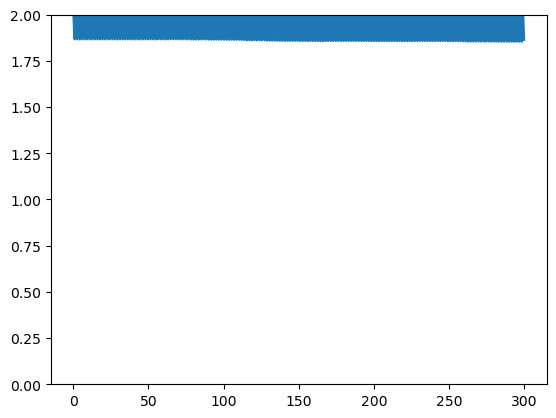

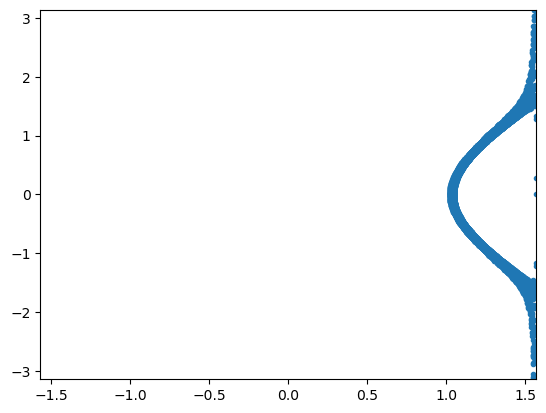

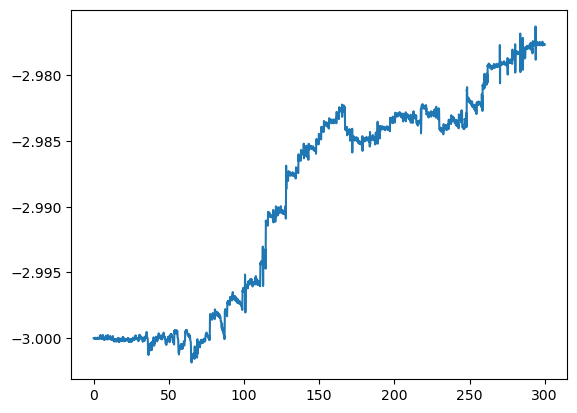

In [147]:
exNLmean = mean_funcs.N_L(points,U_0,t_list,mu)
plt.plot(t_list,exNLmean)
plt.ylim(0,2)
plt.show()

(theta,phi) = mean_funcs.meanTraj_thetaphi(points, U_0, t_list, mu)

phi = (phi + np.pi) % (2*np.pi) - np.pi
plt.plot(theta,phi,'.')
plt.xlim(-np.pi/2,np.pi/2)
plt.ylim(-np.pi,np.pi)
plt.show()

E = mean_funcs.E(mu,theta,phi)
plt.plot(t_list,E)
plt.show()

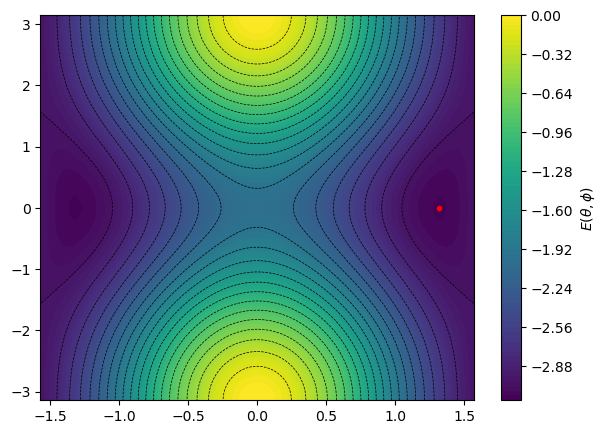

In [139]:
theta_grid = np.linspace(-np.pi/2, np.pi/2, 600)
phi_grid = np.linspace(-np.pi, np.pi, 600)

THETA, PHI = np.meshgrid(theta_grid, phi_grid)
ENERGY = mean_funcs.E(mu, THETA, PHI)


plt.figure(figsize=(7,5))
plt.contourf(THETA, PHI, ENERGY, levels=80, cmap='viridis')
plt.colorbar(label=r'$E(\theta,\phi)$')
plt.contour(THETA, PHI, ENERGY, levels=20, colors="black", linewidths=0.5)
plt.plot(1.318,0,'r.')
plt.show()